<a href="https://colab.research.google.com/github/AlbinJosephcode/12-Steps-to-Navier-Stokes/blob/main/1D%20Burger's%20equation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

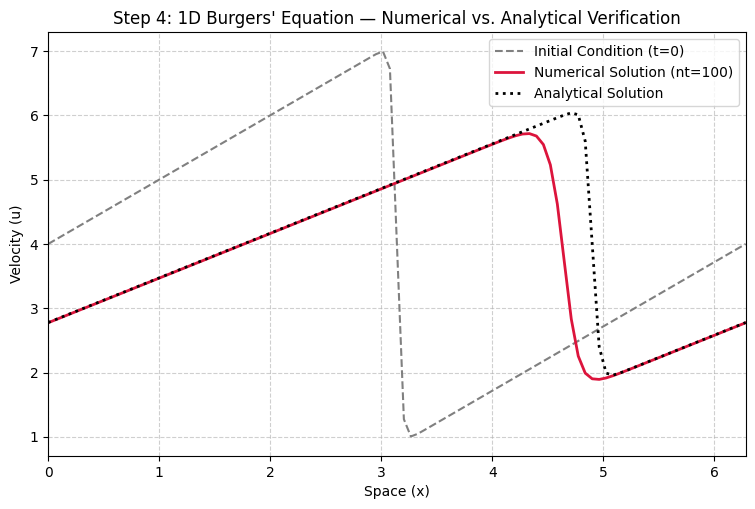

In [1]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

nx = 101                         # Number of spatial grid points
dx = 2 * np.pi / (nx - 1)        # Grid spacing (periodic domain: 0 to 2*pi)
nt = 100                         # Number of time steps
nu = 0.07                        # Kinematic viscosity
dt = dx * nu                     # Time step size chosen for stability

x = np.linspace(0, 2 * np.pi, nx)

x_sym, nu_sym, t_sym = sp.symbols('x nu t')

# Potential function phi(x, t)
phi = (sp.exp(-(x_sym - 4 * t_sym)**2 / (4 * nu_sym * (t_sym + 1))) +
       sp.exp(-(x_sym - 4 * t_sym - 2 * np.pi)**2 / (4 * nu_sym * (t_sym + 1))))

# Exact spatial derivative of phi
phiprime = phi.diff(x_sym)

# Cole-Hopf exact velocity field: u = -2*nu*(dphi/dx)/phi + 4
u_sym = -2 * nu_sym * (phiprime / phi) + 4

# Lambdify for fast numerical evaluation
ufunc = sp.lambdify((t_sym, x_sym, nu_sym), u_sym)

# Set initial condition (t = 0)
u = np.asarray([ufunc(0, x_val, nu) for x_val in x])
u_initial = u.copy()

# Matrix to store solution history for 3D plot
u_history = np.zeros((nt + 1, nx))
u_history[0, :] = u.copy()

for n in range(nt):
    un = u.copy()

    # Interior points update (Nonlinear Convection + Linear Diffusion)
    for i in range(1, nx - 1):
        u[i] = (un[i]
                - un[i] * (dt / dx) * (un[i] - un[i - 1])
                + nu * (dt / dx**2) * (un[i + 1] - 2 * un[i] + un[i - 1]))

    # Periodic boundary condition: u[0] connects to u[-2]
    u[0] = (un[0]
            - un[0] * (dt / dx) * (un[0] - un[-2])
            + nu * (dt / dx**2) * (un[1] - 2 * un[0] + un[-2]))
    u[-1] = u[0]

    # Store history
    u_history[n + 1, :] = u.copy()

# Evaluate analytical solution at final time (t_final = nt * dt)
u_analytical = np.asarray([ufunc(nt * dt, x_val, nu) for x_val in x])


plt.figure(figsize=(9, 5.5))
plt.plot(x, u_initial, label='Initial Condition (t=0)', linestyle='--', color='gray')
plt.plot(x, u, label=f'Numerical Solution (nt={nt})', color='crimson', linewidth=2)
plt.plot(x, u_analytical, label='Analytical Solution', color='black', linestyle=':', linewidth=2)
plt.xlabel('Space (x)')
plt.ylabel('Velocity (u)')
plt.title("Step 4: 1D Burgers' Equation — Numerical vs. Analytical Verification")
plt.xlim([0, 2 * np.pi])
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

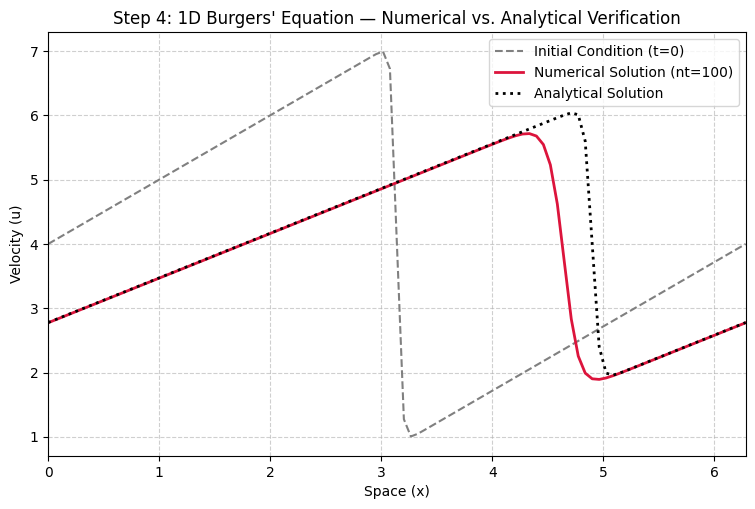

In [2]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

# ==========================================
# 1. PARAMETERS & GRID SETUP
# ==========================================
nx = 101                         # Number of spatial grid points
dx = 2 * np.pi / (nx - 1)        # Grid spacing (periodic domain: 0 to 2*pi)
nt = 100                         # Number of time steps
nu = 0.07                        # Kinematic viscosity
dt = dx * nu                     # Time step size chosen for stability

x = np.linspace(0, 2 * np.pi, nx)

# ==========================================
# 2. ANALYTICAL SOLUTION VIA SYMPY (COLE-HOPF)
# ==========================================
x_sym, nu_sym, t_sym = sp.symbols('x nu t')

# Potential function phi(x, t)
phi = (sp.exp(-(x_sym - 4 * t_sym)**2 / (4 * nu_sym * (t_sym + 1))) +
       sp.exp(-(x_sym - 4 * t_sym - 2 * np.pi)**2 / (4 * nu_sym * (t_sym + 1))))

# Exact spatial derivative of phi
phiprime = phi.diff(x_sym)

# Cole-Hopf exact velocity field: u = -2*nu*(dphi/dx)/phi + 4
u_sym = -2 * nu_sym * (phiprime / phi) + 4

# Lambdify for fast numerical evaluation
ufunc = sp.lambdify((t_sym, x_sym, nu_sym), u_sym)

# Set initial condition (t = 0)
u = np.asarray([ufunc(0, x_val, nu) for x_val in x])
u_initial = u.copy()

# Matrix to store solution history for 3D plot
u_history = np.zeros((nt + 1, nx))
u_history[0, :] = u.copy()

for n in range(nt):
    un = u.copy()

    # Interior points update (Nonlinear Convection + Linear Diffusion)
    for i in range(1, nx - 1):
        u[i] = (un[i]
                - un[i] * (dt / dx) * (un[i] - un[i - 1])
                + nu * (dt / dx**2) * (un[i + 1] - 2 * un[i] + un[i - 1]))

    # Periodic boundary condition: u[0] connects to u[-2]
    u[0] = (un[0]
            - un[0] * (dt / dx) * (un[0] - un[-2])
            + nu * (dt / dx**2) * (un[1] - 2 * un[0] + un[-2]))
    u[-1] = u[0]

    # Store history
    u_history[n + 1, :] = u.copy()

# Evaluate analytical solution at final time (t_final = nt * dt)
u_analytical = np.asarray([ufunc(nt * dt, x_val, nu) for x_val in x])

plt.figure(figsize=(9, 5.5))
plt.plot(x, u_initial, label='Initial Condition (t=0)', linestyle='--', color='gray')
plt.plot(x, u, label=f'Numerical Solution (nt={nt})', color='crimson', linewidth=2)
plt.plot(x, u_analytical, label='Analytical Solution', color='black', linestyle=':', linewidth=2)
plt.xlabel('Space (x)')
plt.ylabel('Velocity (u)')
plt.title("Step 4: 1D Burgers' Equation — Numerical vs. Analytical Verification")
plt.xlim([0, 2 * np.pi])
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()